### Импорт библиотек

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from pathlib import Path

### Инициализация констант

In [2]:
# Параметры согласно варианту
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
NUM_EPOCHS = 15

data_dir = "dataset/dogs-vs-cats"
DATASET_PATH = f"{data_dir}-split"

# Создаем необходимые директории
Path("dataset").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)

### Загрузка данных

In [3]:
def check_and_prepare_data():
    """Проверяет и подготавливает данные"""
    # if Path(f"{data_dir}/train").exists():
    #   print("Данные подготовлены")
    #   return True

    if not Path(data_dir).exists():
        print("Исходные данные не найдены.")
        print("Пожалуйста, выполните следующие шаги:")
        print("1. Скачайте датасет с: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset")
        print("2. Распакуйте в папку 'datasets/dogs-vs-cats'")
        print("3. Запустите код снова")
        return False

    print("Организация данных...")
    organize_dataset()
    print("Разделение данных...")
    split_dataset()
    return True

def organize_dataset():
    """Организация данных в папки по классам"""
    src_path = f"{data_dir}/train"
    dst_path = f"{data_dir}-organized"

    Path(f"{dst_path}/cats").mkdir(parents=True, exist_ok=True)
    Path(f"{dst_path}/dogs").mkdir(parents=True, exist_ok=True)

    cntr=0
    l = len(os.listdir(src_path))
    for filename in os.listdir(src_path):
        src_file = os.path.join(src_path, filename)
        cntr+= 1
        print(f"Loaded {cntr}/{l}")
        if filename.startswith('cat') and os.path.isfile(src_file):
            shutil.copy2(src_file, f"{dst_path}/cats/{filename}")
        elif filename.startswith('dog') and os.path.isfile(src_file):
            shutil.copy2(src_file, f"{dst_path}/dogs/{filename}")
    print("Данные успешно организованы")

def split_dataset():
    """Разделение данных на train/val/test"""
    try:
        import splitfolders
        splitfolders.ratio(
            f"{data_dir}-organized",
            output=f"{data_dir}-split",
            seed=42,
            ratio=(0.6, 0.2, 0.2),
            group_prefix=None
        )
        print("Данные успешно разделены")
    except ImportError:
        print("splitfolders не установлен, используем ручное разделение")
        manual_split_dataset()

def manual_split_dataset():
    """Ручное разделение данных"""
    import random
    src_path = f"{data_dir}-organized"

    for class_name in ['cats', 'dogs']:
        class_path = os.path.join(src_path, class_name)
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        total = len(images)
        print(f"Total images for class {class_name} = {total}")
        train_end = int(total * 0.6)
        val_end = train_end + int(total * 0.2)

        for split in ['train', 'val', 'test']:
            Path(f"{data_dir}-split/{split}/{class_name}").mkdir(parents=True, exist_ok=True)

        for i, image in enumerate(images):
            src = os.path.join(class_path, image)
            if i < train_end:
                dst = f"{data_dir}-split/train/{class_name}/{image}"
            elif i < val_end:
                dst = f"{data_dir}-split/val/{class_name}/{image}"
            else:
                dst = f"{data_dir}-split/test/{class_name}/{image}"
            shutil.copy2(src, dst)

# Проверяем и подготавливаем данные
print("Проверка данных...")
if not check_and_prepare_data():
    print("Данные не подготовлены. Завершение работы.")
    raise SystemExit("Загрузите данные и запустите код снова")

print("Создание генераторов данных...")

Проверка данных...
Организация данных...
Loaded 1/25000
Loaded 2/25000
Loaded 3/25000
Loaded 4/25000
Loaded 5/25000
Loaded 6/25000
Loaded 7/25000
Loaded 8/25000
Loaded 9/25000
Loaded 10/25000
Loaded 11/25000
Loaded 12/25000
Loaded 13/25000
Loaded 14/25000
Loaded 15/25000
Loaded 16/25000
Loaded 17/25000
Loaded 18/25000
Loaded 19/25000
Loaded 20/25000
Loaded 21/25000
Loaded 22/25000
Loaded 23/25000
Loaded 24/25000
Loaded 25/25000
Loaded 26/25000
Loaded 27/25000
Loaded 28/25000
Loaded 29/25000
Loaded 30/25000
Loaded 31/25000
Loaded 32/25000
Loaded 33/25000
Loaded 34/25000
Loaded 35/25000
Loaded 36/25000
Loaded 37/25000
Loaded 38/25000
Loaded 39/25000
Loaded 40/25000
Loaded 41/25000
Loaded 42/25000
Loaded 43/25000
Loaded 44/25000
Loaded 45/25000
Loaded 46/25000
Loaded 47/25000
Loaded 48/25000
Loaded 49/25000
Loaded 50/25000
Loaded 51/25000
Loaded 52/25000
Loaded 53/25000
Loaded 54/25000
Loaded 55/25000
Loaded 56/25000
Loaded 57/25000
Loaded 58/25000
Loaded 59/25000
Loaded 60/25000
Loaded 6

### Предобработка данных

In [4]:
# Аугментация для тренировочных данных. Помогает модели выделять устойчивые признаки
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, # Нормирование
    rotation_range=20, # Вращение на случайный угол до 20 градусов
    width_shift_range=0.2, # Случайный сдвиг по ширине до 20%
    height_shift_range=0.2, # Случайный сдвиг по высоте до 20%
    horizontal_flip=True, # Случайное горизонтальное отражение
    zoom_range=0.2, # Случайный зум до 20%
    shear_range=0.2,
    fill_mode='nearest' # Заполнение пустых мест ближайшими пикселями
)

# Только рескейлинг для валидации и теста
val_test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [5]:
# Генераторы данных. Загрузка и аугментация данных во время работы
train_generator = train_datagen.flow_from_directory(
    f"{DATASET_PATH}/train",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    f"{DATASET_PATH}/val",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = val_test_datagen.flow_from_directory(
    f"{DATASET_PATH}/test",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"Классы: {train_generator.class_indices}")
print(f"Размер тренировочной выборки: {train_generator.samples}")
print(f"Размер валидационной выборки: {validation_generator.samples}")
print(f"Размер тестовой выборки: {test_generator.samples}")

Found 24371 images belonging to 2 classes.
Found 14774 images belonging to 2 classes.
Found 14754 images belonging to 2 classes.
Классы: {'cats': 0, 'dogs': 1}
Размер тренировочной выборки: 24371
Размер валидационной выборки: 14774
Размер тестовой выборки: 14754


### Построение и обучение моделей

In [6]:
# Основная модель
def create_custom_model():
    model = keras.Sequential()
    
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten()) # Преобразует двухмерную карту признаков в одномерный вектор
    model.add(layers.Dropout(0.5)) # Слой, случайным образом отключающий 50% нейронов во время обучения для борьбы с переобучением

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

custom_model = create_custom_model()
custom_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

custom_model.summary()

/Users/krukrukruzhka/github_projects/ML_magister/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
custom_history = custom_model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=validation_generator,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            filepath='models/best_custom_model.h5',
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

custom_model.save('models/final_custom_model.h5')

Epoch 1/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5664 - loss: 0.6766
Epoch 1: val_loss improved from None to 0.64611, saving model to models/best_custom_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 141s 185ms/step - accuracy: 0.6068 - loss: 0.6515 - val_accuracy: 0.6219 - val_loss: 0.6461
Epoch 2/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6762 - loss: 0.5986
Epoch 2: val_loss improved from 0.64611 to 0.54050, saving model to models/best_custom_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 140s 183ms/step - accuracy: 0.6815 - loss: 0.5939 - val_accuracy: 0.7290 - val_loss: 0.5405
Epoch 3/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7004 - loss: 0.5676
Epoch 3: val_loss improved from 0.54050 to 0.49691, saving model to models/best_custom_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 142s 186ms/step - accuracy: 0.7026 - loss: 0.5633 - val_accuracy: 0.7611 - val_loss: 0.4969
Epoch 4/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7180 - loss: 0.5426
Epoch 4: val_loss improved from 0.49691 to 0.48574, saving model to models/best_custom_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 141s 186ms/step - accuracy: 0.7220 - loss: 0.5407 - val_accuracy: 0.7613 - val_loss: 0.4857
Epoch 5/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7303 - loss: 0.5276
Epoch 5: val_loss improved from 0.48574 to 0.48199, saving model to models/best_custom_model.h5


...

762/762 ━━━━━━━━━━━━━━━━━━━━ 139s 182ms/step - accuracy: 0.7481 - loss: 0.5058 - val_accuracy: 0.7894 - val_loss: 0.4500
Epoch 7/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7578 - loss: 0.4958
Epoch 7: val_loss improved from 0.45000 to 0.43028, saving model to models/best_custom_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 139s 182ms/step - accuracy: 0.7620 - loss: 0.4917 - val_accuracy: 0.8017 - val_loss: 0.4303
Epoch 8/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7616 - loss: 0.4881
Epoch 8: val_loss did not improve from 0.43028
762/762 ━━━━━━━━━━━━━━━━━━━━ 136s 178ms/step - accuracy: 0.7657 - loss: 0.4833 - val_accuracy: 0.7529 - val_loss: 0.4976
Epoch 9/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7724 - loss: 0.4747
Epoch 9: val_loss improved from 0.43028 to 0.40336, saving model to models/best_custom_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 136s 178ms/step - accuracy: 0.7755 - loss: 0.4711 - val_accuracy: 0.8175 - val_loss: 0.4034
Epoch 10/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7825 - loss: 0.4560
Epoch 10: val_loss did not improve from 0.40336
762/762 ━━━━━━━━━━━━━━━━━━━━ 137s 179ms/step - accuracy: 0.7795 - loss: 0.4598 - val_accuracy: 0.8137 - val_loss: 0.4123
Epoch 11/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7854 - loss: 0.4534
Epoch 11: val_loss did not improve from 0.40336
762/762 ━━━━━━━━━━━━━━━━━━━━ 136s 179ms/step - accuracy: 0.7859 - loss: 0.4527 - val_accuracy: 0.8131 - val_loss: 0.4119
Epoch 12/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7867 - loss: 0.4530
Epoch 12: val_loss did not improve from 0.40336
762/762 ━━━━━━━━━━━━━━━━━━━━ 137s 180ms/step - accuracy: 0.7895 - loss: 0.4467 - val_accuracy: 0.8119 - val_loss: 0.4219
Epoch 13/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7965 - loss: 0.4358
Epoch 13: val_lo

762/762 ━━━━━━━━━━━━━━━━━━━━ 137s 180ms/step - accuracy: 0.7929 - loss: 0.4387 - val_accuracy: 0.8401 - val_loss: 0.3644
Epoch 14/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8011 - loss: 0.4348
Epoch 14: val_loss improved from 0.36444 to 0.34759, saving model to models/best_custom_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 136s 178ms/step - accuracy: 0.8028 - loss: 0.4292 - val_accuracy: 0.8478 - val_loss: 0.3476
Epoch 15/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8069 - loss: 0.4172
Epoch 15: val_loss did not improve from 0.34759
762/762 ━━━━━━━━━━━━━━━━━━━━ 135s 177ms/step - accuracy: 0.8044 - loss: 0.4226 - val_accuracy: 0.8495 - val_loss: 0.3540
Restoring model weights from the end of the best epoch: 14.


In [8]:
# Базовая модель
def create_baseline_model():
    model = keras.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))  # Дополнительный слой
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.Flatten())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

baseline_model = create_baseline_model()
baseline_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
baseline_history = baseline_model.fit(
    train_generator,
    epochs=NUM_EPOCHS,
    validation_data=validation_generator,
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            filepath='models/best_baseline_model.h5',
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

baseline_model.save('models/final_baseline_model.h5')

Epoch 1/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5490 - loss: 0.6821
Epoch 1: val_loss improved from None to 0.61483, saving model to models/best_baseline_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 121s 158ms/step - accuracy: 0.5787 - loss: 0.6695 - val_accuracy: 0.6580 - val_loss: 0.6148
Epoch 2/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6511 - loss: 0.6195
Epoch 2: val_loss improved from 0.61483 to 0.55878, saving model to models/best_baseline_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 122s 160ms/step - accuracy: 0.6612 - loss: 0.6100 - val_accuracy: 0.7112 - val_loss: 0.5588
Epoch 3/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6894 - loss: 0.5795
Epoch 3: val_loss improved from 0.55878 to 0.51492, saving model to models/best_baseline_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 121s 159ms/step - accuracy: 0.6946 - loss: 0.5741 - val_accuracy: 0.7473 - val_loss: 0.5149
Epoch 4/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7109 - loss: 0.5522
Epoch 4: val_loss improved from 0.51492 to 0.50508, saving model to models/best_baseline_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 121s 158ms/step - accuracy: 0.7131 - loss: 0.5506 - val_accuracy: 0.7477 - val_loss: 0.5051
Epoch 5/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7324 - loss: 0.5302
Epoch 5: val_loss improved from 0.50508 to 0.45935, saving model to models/best_baseline_model.h5


...

762/762 ━━━━━━━━━━━━━━━━━━━━ 121s 159ms/step - accuracy: 0.7714 - loss: 0.4739 - val_accuracy: 0.8193 - val_loss: 0.3985
Epoch 9/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7865 - loss: 0.4563
Epoch 9: val_loss did not improve from 0.39855
762/762 ━━━━━━━━━━━━━━━━━━━━ 120s 157ms/step - accuracy: 0.7863 - loss: 0.4551 - val_accuracy: 0.7980 - val_loss: 0.4270
Epoch 10/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7864 - loss: 0.4548
Epoch 10: val_loss improved from 0.39855 to 0.38153, saving model to models/best_baseline_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 121s 158ms/step - accuracy: 0.7845 - loss: 0.4535 - val_accuracy: 0.8314 - val_loss: 0.3815
Epoch 11/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7990 - loss: 0.4344
Epoch 11: val_loss improved from 0.38153 to 0.35040, saving model to models/best_baseline_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 126s 166ms/step - accuracy: 0.7989 - loss: 0.4363 - val_accuracy: 0.8491 - val_loss: 0.3504
Epoch 12/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8021 - loss: 0.4226
Epoch 12: val_loss improved from 0.35040 to 0.34678, saving model to models/best_baseline_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 131s 171ms/step - accuracy: 0.8033 - loss: 0.4227 - val_accuracy: 0.8496 - val_loss: 0.3468
Epoch 13/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8054 - loss: 0.4198
Epoch 13: val_loss improved from 0.34678 to 0.31708, saving model to models/best_baseline_model.h5


762/762 ━━━━━━━━━━━━━━━━━━━━ 135s 177ms/step - accuracy: 0.8108 - loss: 0.4145 - val_accuracy: 0.8637 - val_loss: 0.3171
Epoch 14/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8130 - loss: 0.4049
Epoch 14: val_loss did not improve from 0.31708
762/762 ━━━━━━━━━━━━━━━━━━━━ 128s 168ms/step - accuracy: 0.8150 - loss: 0.4019 - val_accuracy: 0.8602 - val_loss: 0.3247
Epoch 15/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8247 - loss: 0.3913
Epoch 15: val_loss did not improve from 0.31708
762/762 ━━━━━━━━━━━━━━━━━━━━ 125s 164ms/step - accuracy: 0.8251 - loss: 0.3905 - val_accuracy: 0.8517 - val_loss: 0.3419
Restoring model weights from the end of the best epoch: 13.


### Графики и оценка качества

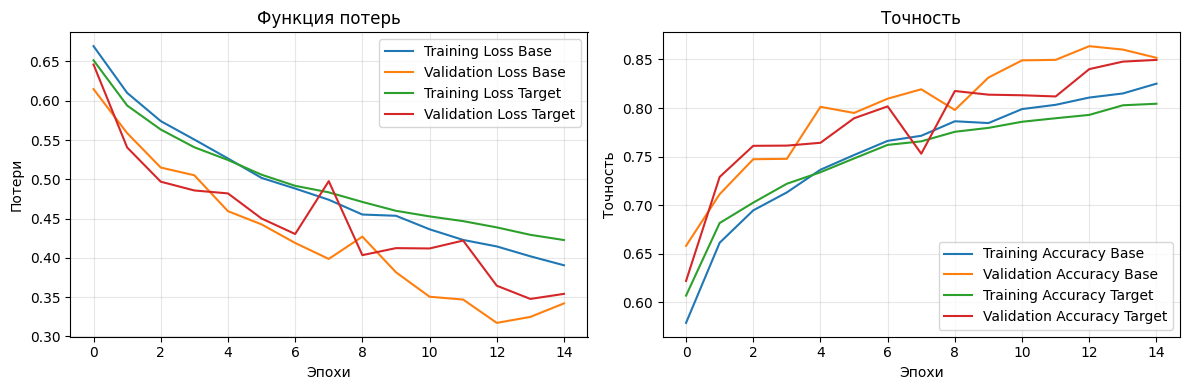

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Training Loss Base')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss Base')
plt.plot(custom_history.history['loss'], label='Training Loss Target')
plt.plot(custom_history.history['val_loss'], label='Validation Loss Target')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['accuracy'], label='Training Accuracy Base')
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy Base')
plt.plot(custom_history.history['accuracy'], label='Training Accuracy Target')
plt.plot(custom_history.history['val_accuracy'], label='Validation Accuracy Target')
plt.title('Точность')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [11]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator, verbose=0)
print(f"Базовая модель - Тестовая точность: {baseline_test_acc:.4f}")

custom_test_loss, custom_test_acc = custom_model.evaluate(test_generator, verbose=0)
print(f"Основная модель - Тестовая точность: {custom_test_acc:.4f}")

Базовая модель - Тестовая точность: 0.8630
Основная модель - Тестовая точность: 0.8479


#### Вывод
Базовая модель отработала на несколько процентов лучше

### Предсказание на тестовых данных

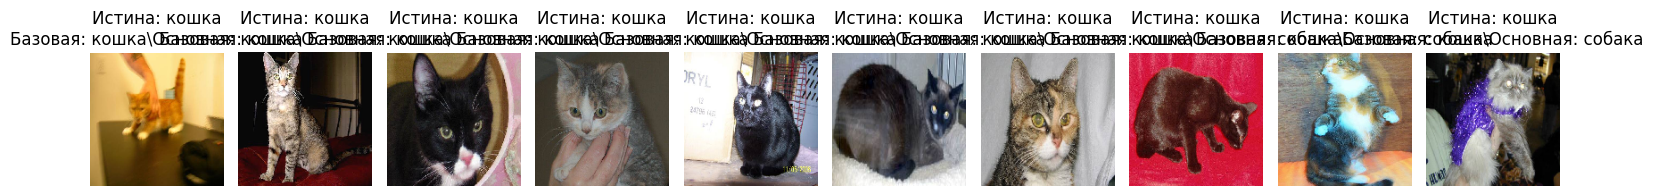

In [12]:
test_images, test_labels = next(test_generator)
num_demo = min(10, BATCH_SIZE)

plt.figure(figsize=(15, 3))
for i in range(num_demo):
    image = test_images[i]
    true_label = "кошка" if test_labels[i] == 0 else "собака"

    baseline_pred = baseline_model.predict(np.expand_dims(image, axis=0), verbose=0)[0][0]
    custom_pred = custom_model.predict(np.expand_dims(image, axis=0), verbose=0)[0][0]

    baseline_class = "кошка" if baseline_pred < 0.5 else "собака"
    custom_class = "кошка" if custom_pred < 0.5 else "собака"

    plt.subplot(1, num_demo, i + 1)
    plt.imshow(image)
    plt.title(f'Истина: {true_label}\nБазовая: {baseline_class}\Основная: {custom_class}')
    plt.axis('off')

plt.tight_layout()
plt.show()